## Min identity 0.8 - low high input comparison in monoclonal antibody 1
### filtering peptides >= 7 and minimum 0.9 confidence score


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
from pathlib import Path
from Bio import SeqIO
import json
import os
import logging
import numpy as np
from scipy.stats import mannwhitneyu

# Import all our custom pipeline modules
from instanexus import preprocessing
from instanexus import assembly
from instanexus import clustering
from instanexus import alignment
from instanexus import consensus
from instanexus import visualization
from instanexus import helpers

# Set up logging to see the pipeline's progress
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [3]:
os.chdir('../../../../')

print(f"Current working directory: {os.getcwd()}")

Current working directory: /Users/marcor/Desktop/projects/InstaNexus


In [4]:
FIGURES_DIR = Path("figures")
print(FIGURES_DIR)

figures


In [5]:
# Path to the new raw data you want to test
#INPUT_CSV = "_archive/csv/v2/bsa.csv"
#INPUT_CSV = "inputs/bsa.csv"
INPUT_CSV_1 = "inputs/ma1_low.csv"
INPUT_CSV_2 = "inputs/ma1_high.csv"

BASE_OUTPUT_FOLDER = "outputs_notebook"

METADATA_PATH = "json/sample_metadata.json"
CONTAMINANTS_PATH = "fasta/contaminants.fasta"

RUN_NAME = Path(INPUT_CSV_1).stem
REFERENCE_MODE = True
CHAIN = "light"  # "heavy" or "light"

# Filtering params
CONFIDENCE_THRESHOLD = 0.9
# MASS_ERR_LIMIT = 20
MIN_LENGTH = 7
MAX_LENGTH = 20
# MAX_IRT_ERROR = 60
# MIN_ENTROPY = 1
# PROSIT_FILTER = True
FDR_THRESHOLD = 0.1
# Z_SCORE_THRESHOLD = -0.5

# Assembly params
ASSEMBLY_MODE = "dbg_weighted"
KMER_SIZE = 6
MIN_OVERLAP = 3
SIZE_THRESHOLD = 10

MIN_IDENTITY = 0.8
MAX_MISMATCHES = 0

# Clustering params
MIN_SEQ_ID = 0.85
COVERAGE = 0.8

In [6]:
sample_metadata = preprocessing.get_sample_metadata(
    run="ma1", 
    chain=CHAIN, 
    json_path=METADATA_PATH
)

In [7]:
proteases = sample_metadata["proteases"]
protein = sample_metadata["protein"]
protein_norm = preprocessing.normalize_sequence(protein)

In [8]:
print(f"Sample uses proteases: {proteases}")
print(f"Protein sequence length: {len(protein)} amino acids")
print(f"Normalized protein sequence: {protein_norm}")

Sample uses proteases: ['Thermo', 'Papain', 'Chemo', 'Trypsin', 'Elastase', 'ProtK', 'GluC']
Protein sequence length: 213 amino acids
Normalized protein sequence: DLVMTQSPSSLSASVGDRVTLTCQASQDLSNYLNWYQQKPGKAPKLLLYAASSLESGVPSRFSGSGSGTEFTLTLTNLQVDDFATYYCQRYDSNFAFGQGTKVELKRTVAAPSVFLFPPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGEC


In [9]:
ma1_low = pd.read_csv(INPUT_CSV_1)
ma1_high = pd.read_csv(INPUT_CSV_2)

In [10]:
ma1_low.columns

Index(['scan_number', 'precursor_mz', 'precursor_charge', 'experiment_name',
       'spectrum_id', 'preds', 'preds_tokenised', 'log_probs',
       'token_log_probs', 'delta_mass_ppm'],
      dtype='object')

In [11]:
ma1_low["protease"] = ma1_low["experiment_name"].apply(
    lambda name: preprocessing.extract_protease(name, proteases)
)

protease_col = ma1_low.pop("protease")
ma1_low.insert(ma1_low.columns.get_loc("preds") + 1, "protease", protease_col)
ma1_low.head(3)

,scan_number,precursor_mz,precursor_charge,experiment_name,spectrum_id,preds,protease,preds_tokenised,log_probs,token_log_probs,delta_mass_ppm
0,580,781.136047,4,20251212_MH_ELBE_RNOJO_FAIMS_1CV_uPAC50_38min_...,20251212_MH_ELBE_RNOJO_FAIMS_1CV_uPAC50_38min_...,GAAAAAAAAAAAAAPAWEAAAAPAWEAAAPAPEEK,None,"G, A, A, A, A, A, A, A, A, A, A, A, A, A, P, A...",-116.453156,"[-3.0223441123962402, -1.6670808792114258, -1....",1917.410057
1,592,607.947571,3,20251212_MH_ELBE_RNOJO_FAIMS_1CV_uPAC50_38min_...,20251212_MH_ELBE_RNOJO_FAIMS_1CV_uPAC50_38min_...,[UNIMOD:1]EEEKDKGDEEEEGEK,None,"[UNIMOD:1], E, E, E, K, D, K, G, D, E, E, E, E...",-22.440437,"[-7.651631832122803, -0.004024621564894915, -0...",42.367909
2,594,606.280090,3,20251212_MH_ELBE_RNOJO_FAIMS_1CV_uPAC50_38min_...,20251212_MH_ELBE_RNOJO_FAIMS_1CV_uPAC50_38min_...,SSSSSSSSVSVSSLSSLSK,None,"S, S, S, S, S, S, S, S, V, S, V, S, S, L, S, S...",-285.704987,"[-1.2026318311691284, -1.0671517848968506, -1....",14270.731966


In [12]:
ma1_low["protease"] = ma1_low["experiment_name"].apply(
    lambda name: preprocessing.extract_protease(name, proteases)
)

protease_col = ma1_low.pop("protease")
ma1_low.insert(ma1_low.columns.get_loc("preds") + 1, "protease", protease_col)
ma1_low.head(3)

,scan_number,precursor_mz,precursor_charge,experiment_name,spectrum_id,preds,protease,preds_tokenised,log_probs,token_log_probs,delta_mass_ppm
0,580,781.136047,4,20251212_MH_ELBE_RNOJO_FAIMS_1CV_uPAC50_38min_...,20251212_MH_ELBE_RNOJO_FAIMS_1CV_uPAC50_38min_...,GAAAAAAAAAAAAAPAWEAAAAPAWEAAAPAPEEK,None,"G, A, A, A, A, A, A, A, A, A, A, A, A, A, P, A...",-116.453156,"[-3.0223441123962402, -1.6670808792114258, -1....",1917.410057
1,592,607.947571,3,20251212_MH_ELBE_RNOJO_FAIMS_1CV_uPAC50_38min_...,20251212_MH_ELBE_RNOJO_FAIMS_1CV_uPAC50_38min_...,[UNIMOD:1]EEEKDKGDEEEEGEK,None,"[UNIMOD:1], E, E, E, K, D, K, G, D, E, E, E, E...",-22.440437,"[-7.651631832122803, -0.004024621564894915, -0...",42.367909
2,594,606.280090,3,20251212_MH_ELBE_RNOJO_FAIMS_1CV_uPAC50_38min_...,20251212_MH_ELBE_RNOJO_FAIMS_1CV_uPAC50_38min_...,SSSSSSSSVSVSSLSSLSK,None,"S, S, S, S, S, S, S, S, V, S, V, S, S, L, S, S...",-285.704987,"[-1.2026318311691284, -1.0671517848968506, -1....",14270.731966


In [13]:
ma1_high["protease"] = ma1_high["experiment_name"].apply(
    lambda name: preprocessing.extract_protease(name, proteases)
)

protease_col = ma1_high.pop("protease")
ma1_high.insert(ma1_high.columns.get_loc("preds") + 1, "protease", protease_col)
ma1_high.head(3)

,scan_number,precursor_mz,precursor_charge,experiment_name,spectrum_id,preds,protease,preds_tokenised,log_probs,token_log_probs,delta_mass_ppm
0,49,512.363159,2,20240628_FJ_Jubba_MP_Easy15_35min_1835_DDA_The...,20240628_FJ_Jubba_MP_Easy15_35min_1835_DDA_The...,GEAILAALEK,Thermo,"G, E, A, I, L, A, A, L, E, K",-353.300873,"[-3.582167148590088, -1.0445810556411743, -1.7...",7936.430649
1,52,492.392609,2,20240628_FJ_Jubba_MP_Easy15_35min_1835_DDA_The...,20240628_FJ_Jubba_MP_Easy15_35min_1835_DDA_The...,SLLRSLLK,Thermo,"S, L, L, R, S, L, L, K",-399.231720,"[-1.267818570137024, -1.304776668548584, -1.10...",53981.648335
2,56,399.349457,2,20240628_FJ_Jubba_MP_Easy15_35min_1835_DDA_The...,20240628_FJ_Jubba_MP_Easy15_35min_1835_DDA_The...,RELLSK,Thermo,"R, E, L, L, S, K",-410.713348,"[-1.1180181503295898, -1.9968715906143188, -0....",64143.806513


In [14]:
print(ma1_low.shape[0])
print(ma1_high.shape[0])


216879
78321


In [15]:
ma1_low = ma1_low.dropna(subset=["preds"])
ma1_high = ma1_high.dropna(subset=["preds"])

In [16]:
print(ma1_low.shape[0])
print(ma1_high.shape[0])


216879
78321


In [17]:
ma1_low["cleaned_preds"] = ma1_low["preds"].apply(preprocessing.remove_modifications)
ma1_high["cleaned_preds"] = ma1_high["preds"].apply(preprocessing.remove_modifications)

In [18]:
# make a column called number_amino_acids
ma1_low["number_amino_acids"] = ma1_low["cleaned_preds"].apply(len)
ma1_high["number_amino_acids"] = ma1_high["cleaned_preds"].apply(len)

In [19]:
# convert the column log_probs in the exponential scale
ma1_low["exp_log_probs"] = ma1_low["log_probs"].apply(np.exp)
ma1_high["exp_log_probs"] = ma1_high["log_probs"].apply(np.exp)

In [20]:
# filter based on exp_log_probs and number_amino_acids: exp_log_probs > 0.9 and number_amino_acids >= 7
ma1_low_filtered = ma1_low[(ma1_low["exp_log_probs"] > CONFIDENCE_THRESHOLD) & (ma1_low["number_amino_acids"] >= MIN_LENGTH) & (ma1_low["number_amino_acids"] <= MAX_LENGTH)]
ma1_high_filtered = ma1_high[(ma1_high["exp_log_probs"] > CONFIDENCE_THRESHOLD) & (ma1_high["number_amino_acids"] >= MIN_LENGTH) & (ma1_high["number_amino_acids"] <= MAX_LENGTH)]

In [21]:
print(ma1_low_filtered.shape[0])
print(ma1_high_filtered.shape[0])


1484
1480


In [22]:
cleaned_psms_low = ma1_low_filtered["cleaned_preds"].tolist()
cleaned_psms_high = ma1_high_filtered["cleaned_preds"].tolist()

In [23]:
print(MAX_MISMATCHES)
print(MIN_IDENTITY)

0
0.8


In [24]:
mapped_psms_low = visualization.process_protein_contigs_scaffold(
    cleaned_psms_low, protein_norm, MAX_MISMATCHES, MIN_IDENTITY
)

mapped_psms_high = visualization.process_protein_contigs_scaffold(
    cleaned_psms_high, protein_norm, MAX_MISMATCHES, MIN_IDENTITY
)

In [25]:
print(len(mapped_psms_low))
print(len(mapped_psms_high))

513
563


In [26]:
df_psms_mapped_low = visualization.create_dataframe_from_mapped_sequences(data=mapped_psms_low)
df_psms_mapped_high = visualization.create_dataframe_from_mapped_sequences(data=mapped_psms_high)

In [27]:
df_psms_mapped_low.head(3)

,sequence,start,end,mismatches_pos,identity_score
0,YQQKPGKAPK,35,45,[],1.0
1,ACEVTHQG,191,199,[],1.0
2,LSKADYEKHK,179,189,[],1.0


In [28]:
stats_low = helpers.compute_assembly_statistics(
    df_psms_mapped_low, f"psms_{CHAIN}_low", "./outputs/_low_high_input", protein_norm
)

stats_high = helpers.compute_assembly_statistics(
    df_psms_mapped_high, f"psms_{CHAIN}_high", "./outputs/_low_high_input", protein_norm
)

## Barplot comparison

In [41]:
base_folder = "./outputs/_low_high_input" # o il percorso corretto dove hai salvato i json

files_map = {
    ('Light Chain', 'Low Input'): os.path.join(base_folder, "psms_light_low_stats.json"),
    ('Light Chain', 'High Input'): os.path.join(base_folder, "psms_light_high_stats.json"),
    ('Heavy Chain', 'Low Input'): os.path.join(base_folder, "psms_heavy_low_stats.json"),
    ('Heavy Chain', 'High Input'): os.path.join(base_folder, "psms_heavy_high_stats.json"),
}

In [42]:
data = []

for (chain, input_type), file_path in files_map.items():
    try:
        with open(file_path, 'r') as f:
            stats = json.load(f)
            coverage_pct = stats['coverage'] * 100 
            data.append({
                'Chain': chain,
                'Input': input_type,
                'Coverage': coverage_pct
            })
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        data.append({'Chain': chain, 'Input': input_type, 'Coverage': 0})

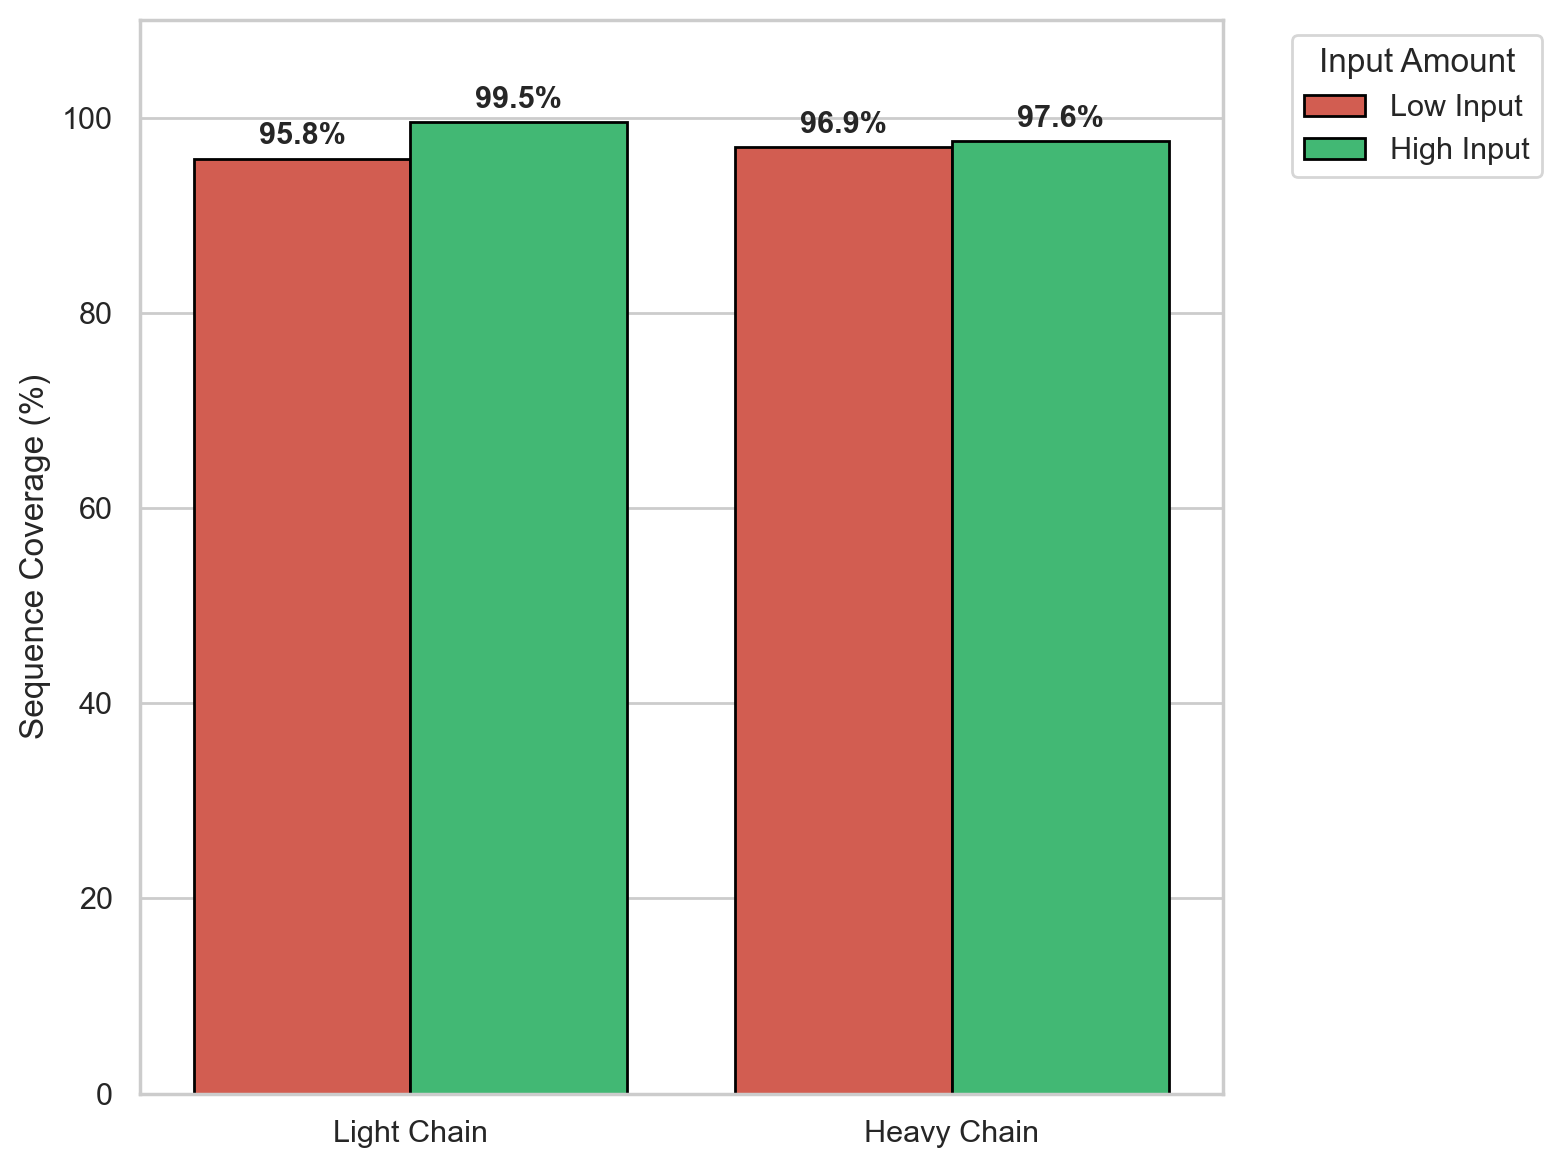

In [43]:
df_plot = pd.DataFrame(data)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

custom_palette = {'Low Input': '#e74c3c', 'High Input': '#2ecc71'}

ax = sns.barplot(
    data=df_plot,
    x='Chain',
    y='Coverage',
    hue='Input',
    palette=custom_palette,
    edgecolor="black",
    linewidth=1
)

plt.ylabel('Sequence Coverage (%)', fontsize=12)
plt.xlabel('')
plt.ylim(0, 110)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%',
    padding=3, fontsize=11, fontweight='bold')

plt.legend(title='Input Amount', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(base_folder, "psms_coverage_barplot.png"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(base_folder, "psms_coverage_barplot.svg"), format='svg', bbox_inches='tight')
plt.show()

## Scaffolds

In [29]:
assembler = assembly.Assembler(
    mode="dbg_weighted",
    kmer_size=7,
    min_overlap=3,
    size_threshold=10,
    min_weight=2,
    refine_rounds=5
)

In [30]:
scaffolds_low = assembler.run(sequences=cleaned_psms_low, df_full=ma1_low_filtered)
scaffolds_high = assembler.run(sequences=cleaned_psms_high, df_full=ma1_high_filtered)

2025-12-22 17:37:55,097 [INFO] [Assembler] Running DBG weighted (k=7, min_weight=2)
Assembling contigs: 100%|██████████| 719/719 [00:00<00:00, 276340.56it/s]
2025-12-22 17:37:55,147 [INFO] DBG produced 58 initial contigs.
2025-12-22 17:37:55,148 [INFO] Refining contigs using Overlap Graph (Bird's Eye View)...
2025-12-22 17:37:55,157 [INFO] DEBUG: Overlap Graph has 58 nodes and 20 edges.
2025-12-22 17:37:55,159 [INFO] Round 1: reduced to 44 scaffolds.
2025-12-22 17:37:55,165 [INFO] DEBUG: Overlap Graph has 44 nodes and 0 edges.
2025-12-22 17:37:55,165 [WARNING] No overlaps found between scaffolds! Check sliding logic.
2025-12-22 17:37:55,166 [INFO] Refinement converged at round 2.
2025-12-22 17:37:55,167 [INFO] [Assembler] Running DBG weighted (k=7, min_weight=2)
Assembling contigs: 100%|██████████| 722/722 [00:00<00:00, 619661.86it/s]
2025-12-22 17:37:55,174 [INFO] DBG produced 49 initial contigs.
2025-12-22 17:37:55,174 [INFO] Refining contigs using Overlap Graph (Bird's Eye View)...


In [31]:
mapped_scaffolds_low = visualization.process_protein_contigs_scaffold(
    scaffolds_low, protein_norm, MAX_MISMATCHES, MIN_IDENTITY
)

mapped_scaffolds_high = visualization.process_protein_contigs_scaffold(
    scaffolds_high, protein_norm, MAX_MISMATCHES, MIN_IDENTITY
)

In [32]:
print(len(mapped_scaffolds_high))
print(len(mapped_scaffolds_low))

6
7


In [33]:
df_scaffolds_mapped_low = visualization.create_dataframe_from_mapped_sequences(data=mapped_scaffolds_low)
df_scaffolds_mapped_high = visualization.create_dataframe_from_mapped_sequences(data=mapped_scaffolds_high)

In [34]:
stats_low = helpers.compute_assembly_statistics(
    df_scaffolds_mapped_low, f"scaffolds_{CHAIN}_low", "./outputs/_low_high_input", protein_norm
)

stats_high = helpers.compute_assembly_statistics(
    df_scaffolds_mapped_high, f"scaffolds_{CHAIN}_high", "./outputs/_low_high_input", protein_norm
)

In [38]:
base_folder = "./outputs/_low_high_input" # o il percorso corretto dove hai salvato i json

files_map = {
    ('Light Chain', 'Low Input'): os.path.join(base_folder, "scaffolds_light_low_stats.json"),
    ('Light Chain', 'High Input'): os.path.join(base_folder, "scaffolds_light_high_stats.json"),
    ('Heavy Chain', 'Low Input'): os.path.join(base_folder, "scaffolds_heavy_low_stats.json"),
    ('Heavy Chain', 'High Input'): os.path.join(base_folder, "scaffolds_heavy_high_stats.json"),
}

In [39]:
data = []

for (chain, input_type), file_path in files_map.items():
    try:
        with open(file_path, 'r') as f:
            stats = json.load(f)
            coverage_pct = stats['coverage'] * 100 
            data.append({
                'Chain': chain,
                'Input': input_type,
                'Coverage': coverage_pct
            })
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        data.append({'Chain': chain, 'Input': input_type, 'Coverage': 0})

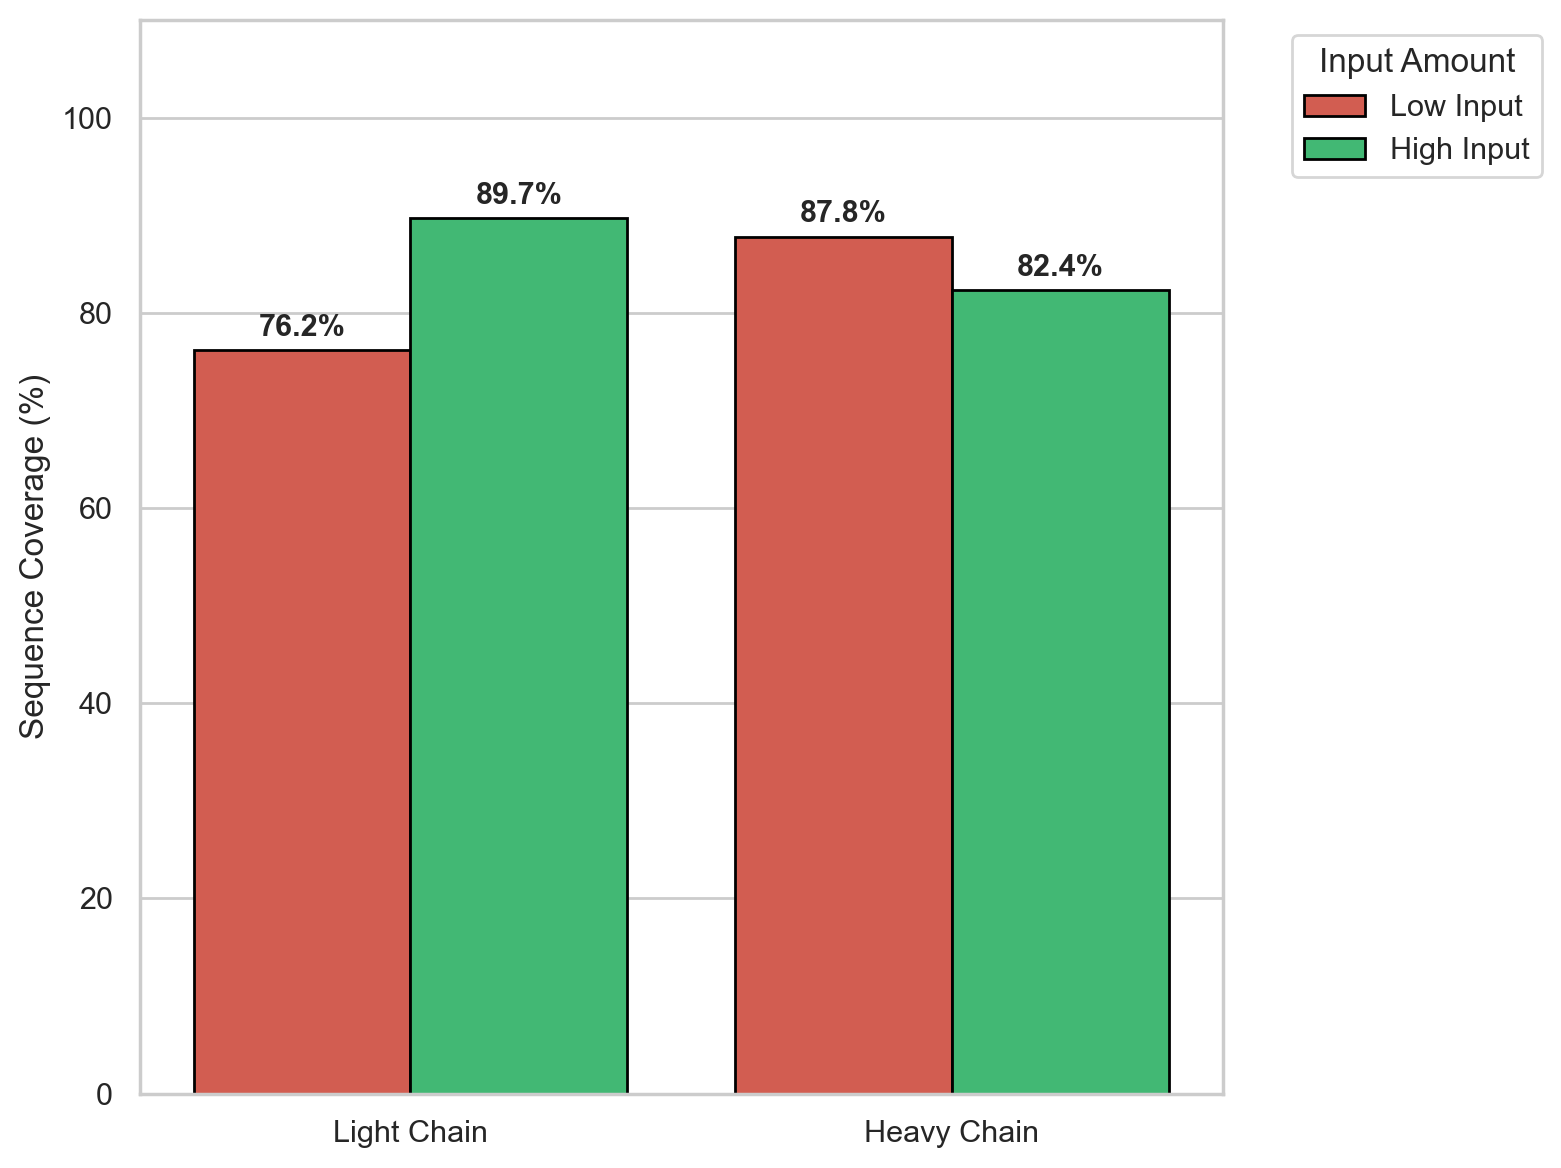

In [40]:
df_plot = pd.DataFrame(data)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

custom_palette = {'Low Input': '#e74c3c', 'High Input': '#2ecc71'}

ax = sns.barplot(
    data=df_plot,
    x='Chain',
    y='Coverage',
    hue='Input',
    palette=custom_palette,
    edgecolor="black",
    linewidth=1
)

plt.ylabel('Sequence Coverage (%)', fontsize=12)
plt.xlabel('')
plt.ylim(0, 110)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%',
    padding=3, fontsize=11, fontweight='bold')

plt.legend(title='Input Amount', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(base_folder, "scaffolds_coverage_barplot.svg"), format='svg', bbox_inches='tight')
plt.show()